## 1. Importing Libraries and Loading Data

In [1]:
import ee
import geopandas as gpd

ee.Authenticate()
ee.Initialize()

## 2. Data Fetching

### 2.1 Fetching Data from Landsat and VIIRS

In [2]:
from spectral import get_spectral, get_viirs

cities = [
    {"code": "CAN", "name": "Ontario"},
    {"code": "IRN", "name": "Tehran"},
    {"code": "NGA", "name": "Lagos"},
	{"code": "FIN", "name": "Uusimaa"},
]

date_range = ("2025-01-01", "2025-12-31")

for city in cities:
    get_spectral(city['code'], city['name'], date_range)
    get_viirs(city['code'], date_range)


c:\Software Projects\Data Projects\uhi-modelling\uhenv\Lib\site-packages\geemap\conversion.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Sample points already exist at data/CAN_sample_points.csv.

VIIRS data already exists at data/CAN_viirs_features.csv.

Sample points already exist at data/IRN_sample_points.csv.

VIIRS data already exists at data/IRN_viirs_features.csv.

Sample points already exist at data/NGA_sample_points.csv.

VIIRS data already exists at data/NGA_viirs_features.csv.

Sample points already exist at data/FIN_sample_points.csv.

VIIRS data already exists at data/FIN_viirs_features.csv.



#### 2.1.1 Inspecting Class Balance of Sampled Points and Missingness

In [3]:
import pandas as pd

for city in cities:
    df = pd.read_csv(f"data/{city['code']}_sample_points.csv")
    urban = (df["LandCover"] == 50).sum()
    rural = (df["LandCover"] != 50).sum()
    print(f"{city['name']}: {urban} urban, {rural} rural, total: {len(df)}")
    
for city in cities:
    df = pd.read_csv(f"data/{city['code']}_viirs_features.csv")
    print(f"{city['name']}: {len(df)} rows")
    print(df[["LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]].isnull().sum())


for city in cities:
    df = pd.read_csv(f"data/{city['code']}_viirs_features.csv")
    missing_months = set(range(1, 13)) - set(df["month"].unique())
    print(f"{city['name']}: missing months {missing_months}")



Ontario: 100 urban, 100 rural, total: 200
Tehran: 100 urban, 100 rural, total: 200
Lagos: 100 urban, 100 rural, total: 200
Uusimaa: 100 urban, 100 rural, total: 200
Ontario: 2400 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Tehran: 2400 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Lagos: 2229 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Uusimaa: 2198 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Ontario: missing months set()
Tehran: missing months set()
Lagos: missing months set()
Uusimaa: missing months {6}


### 2.2 Fetching Met Data from Open-Meteo

In [4]:
from weather import process_city_weather

for city in cities:
    process_city_weather(city['code'], date_range)

Data has already been processed at data/CAN_Full_UHI_Data.csv.

Data has already been processed at data/IRN_Full_UHI_Data.csv.

Data has already been processed at data/NGA_Full_UHI_Data.csv.

Data has already been processed at data/FIN_Full_UHI_Data.csv.



#### 2.2.1 Inspecting Met Data for Missingness

In [5]:
for city in cities:
    df = pd.read_csv(f"data/{city['code']}_Full_UHI_Data.csv")
    print(f"{city['name']}: {len(df)} rows")

Ontario: 4800 rows
Tehran: 4800 rows
Lagos: 4800 rows
Uusimaa: 4800 rows


### 2.3 Concatenating Satellite and Met Data

The city column is added before concatenating.

In [6]:
viirs_dfs, weather_dfs = [], []

for city in cities:
    viirs_df = pd.read_csv(f"data/{city['code']}_viirs_features.csv")
    viirs_df["city"] = city["name"]
    viirs_dfs.append(viirs_df)

    weather_df = pd.read_csv(f"data/{city['code']}_Full_UHI_Data.csv")
    weather_df["city"] = city["name"]
    weather_dfs.append(weather_df)

viirs_data = pd.concat(viirs_dfs, ignore_index=True)
weather_data = pd.concat(weather_dfs, ignore_index=True)

weather_data["date"] = pd.to_datetime(weather_data["date"], utc=True)
weather_data["month"] = weather_data["date"].dt.month
weather_data["time"] = weather_data["date"].dt.hour.map({1: "night", 13: "day"})


uhi_data = weather_data.merge(
    viirs_data,
    on=["latitude", "longitude", "city", "month"],
    how="left"
)

print(uhi_data.shape)
print(uhi_data.head())
print(uhi_data[["LandCover", "Elevation", "LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]].isnull().sum())

(19200, 20)
                       date  humidity  precipitation  wind_speed  \
0 2025-01-01 01:00:00+00:00  96.11895            0.4   16.802786   
1 2025-01-01 13:00:00+00:00  88.68080            0.1   24.203810   
2 2025-02-01 01:00:00+00:00  86.77566            0.0   16.774803   
3 2025-02-01 13:00:00+00:00  80.08138            0.0   11.935778   
4 2025-03-01 01:00:00+00:00  74.14202            0.3   22.040997   

   cloud_cover_low  air_temperature   latitude  longitude  LandCover  \
0            100.0             1.20  43.431842 -80.482495       50.0   
1             65.0             0.35  43.431842 -80.482495       50.0   
2              0.0            -2.55  43.431842 -80.482495       50.0   
3              1.0           -15.65  43.431842 -80.482495       50.0   
4              1.0             2.80  43.431842 -80.482495       50.0   

    Elevation     city  month   time    Albedo   LST_day  LST_night     MNDWI  \
0  325.461426  Ontario      1  night  0.579363  5.272733   5.1836

#### 2.3.1 Inspecting Merge

In [7]:
print(uhi_data[uhi_data["LST_day"].isnull()]["city"].value_counts())
print(uhi_data[uhi_data["LST_day"].isnull()]["month"].value_counts())

uhi_data = uhi_data.sort_values(["city", "latitude", "longitude", "month", "time"]).reset_index(drop=True)

for col in ["LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]:
    uhi_data[col] = uhi_data.groupby(["city", "latitude", "longitude"])[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

print(uhi_data[["LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]].isnull().sum())

city
Uusimaa    404
Lagos      342
Name: count, dtype: int64
month
6     426
3      48
8      36
7      30
12     28
4      28
9      28
2      26
10     26
5      26
11     26
1      18
Name: count, dtype: int64
LST_day      192
LST_night    192
NDVI         192
NDBI         192
MNDWI        192
SAVI         192
Albedo       192
dtype: int64


##### 2.3.1.1 Cleaning Missingness

In [8]:
null_mask = uhi_data["LST_day"].isnull()
print(uhi_data[null_mask]["city"].value_counts())
print(uhi_data[null_mask].groupby(["city", "latitude", "longitude"])["month"].apply(list))

null_pixels = uhi_data[uhi_data["LST_day"].isnull()][["city", "latitude", "longitude"]].drop_duplicates()

uhi_data = uhi_data.merge(
    null_pixels.assign(drop=True),
    on=["city", "latitude", "longitude"],
    how="left"
)
uhi_data = uhi_data[uhi_data["drop"].isnull()].drop(columns=["drop"])

print(uhi_data.shape)
print(uhi_data[["LST_day", "LST_night"]].isnull().sum())
print(uhi_data["city"].value_counts())

city
Lagos    192
Name: count, dtype: int64
city   latitude  longitude
Lagos  6.478715  3.496877     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.479197  3.438773     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.497516  3.556839     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.503954  3.539145     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.512168  3.415794     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.515417  3.518704     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.517941  3.572257     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.577391  3.676986     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
Name: month, dtype: object
(19008, 20)
LST_day      0
LST_night    0
dtype: int64
city
Ontario    4800
Tehran     4800
Uusimaa    4800
Lagos      4608
Name: count, dtype: int64


In [9]:
lagos = uhi_data[uhi_data["city"] == "Lagos"]
print(lagos[["latitude", "longitude", "LandCover"]].drop_duplicates()["LandCover"].value_counts())
print(f"Urban: {(lagos['LandCover'] == 50).sum() // 24}")
print(f"Rural: {(lagos['LandCover'] != 50).sum() // 24}")

LandCover
50.0    100
10.0     40
80.0     23
30.0     14
90.0      7
20.0      5
40.0      1
60.0      1
95.0      1
Name: count, dtype: int64
Urban: 100
Rural: 92


### 2.4 Calculating Urban and Rural Temperatures and SUHI

In [10]:
uhi_data["is_urban"] = (uhi_data["LandCover"] == 50).astype(int)

urban = uhi_data[uhi_data["is_urban"] == 1].groupby(["city", "month", "time"]).agg(
    LST_day_urban=("LST_day", "mean"),
    LST_night_urban=("LST_night", "mean"),
    airtemp_urban=("air_temperature", "mean"),
    n_urban=("LST_day", "count")
).reset_index()

rural = uhi_data[uhi_data["is_urban"] == 0].groupby(["city", "month", "time"]).agg(
    LST_day_rural=("LST_day", "mean"),
    LST_night_rural=("LST_night", "mean"),
    airtemp_rural=("air_temperature", "mean"),
    n_rural=("LST_day", "count")
).reset_index()

uhi_intensity = urban.merge(rural, on=["city", "month", "time"], how="inner")

uhi_intensity["SUHI_day"] = uhi_intensity["LST_day_urban"] - uhi_intensity["LST_day_rural"]
uhi_intensity["SUHI_night"] = uhi_intensity["LST_night_urban"] - uhi_intensity["LST_night_rural"]
uhi_intensity["AUHI"] = uhi_intensity["airtemp_urban"] - uhi_intensity["airtemp_rural"]

uhi_intensity = uhi_intensity.drop(columns=[
    "LST_day_urban", "LST_day_rural",
    "LST_night_urban", "LST_night_rural",
    "airtemp_urban", "airtemp_rural"
])

uhi_data["LST_day"] = uhi_data["LST_day"] / 0.02
uhi_data["LST_night"] = uhi_data["LST_night"] / 0.02

urban = uhi_data[uhi_data["is_urban"] == 1].groupby(["city", "month", "time"]).agg(
    LST_day_urban=("LST_day", "mean"),
    LST_night_urban=("LST_night", "mean"),
    airtemp_urban=("air_temperature", "mean"),
    n_urban=("LST_day", "count")
).reset_index()

rural = uhi_data[uhi_data["is_urban"] == 0].groupby(["city", "month", "time"]).agg(
    LST_day_rural=("LST_day", "mean"),
    LST_night_rural=("LST_night", "mean"),
    airtemp_rural=("air_temperature", "mean"),
    n_rural=("LST_day", "count")
).reset_index()

uhi_intensity = urban.merge(rural, on=["city", "month", "time"], how="inner")
uhi_intensity["SUHI_day"] = uhi_intensity["LST_day_urban"] - uhi_intensity["LST_day_rural"]
uhi_intensity["SUHI_night"] = uhi_intensity["LST_night_urban"] - uhi_intensity["LST_night_rural"]
uhi_intensity["AUHI"] = uhi_intensity["airtemp_urban"] - uhi_intensity["airtemp_rural"]

uhi_intensity = uhi_intensity.drop(columns=[
    "LST_day_urban", "LST_day_rural",
    "LST_night_urban", "LST_night_rural",
    "airtemp_urban", "airtemp_rural"
])

uhi_intensity_wide = uhi_intensity.groupby(["city", "month"]).agg(
    n_urban=("n_urban", "first"),
    n_rural=("n_rural", "first"),
    SUHI_day=("SUHI_day", "mean"),
    SUHI_night=("SUHI_night", "mean"),
    AUHI_day=("AUHI", lambda x: x[uhi_intensity.loc[x.index, "time"] == "day"].values[0]),
    AUHI_night=("AUHI", lambda x: x[uhi_intensity.loc[x.index, "time"] == "night"].values[0])
).reset_index()

uhi_data_model = uhi_data.merge(
    uhi_intensity_wide[["city", "month", "SUHI_day", "SUHI_night", "AUHI_day", "AUHI_night"]],
    on=["city", "month"],
    how="left"
)

# Compute mean rural LST per city per month
rural_means = uhi_data[uhi_data["is_urban"] == 0].groupby(["city", "month"]).agg(
    rural_mean_LST_day=("LST_day", "mean"),
    rural_mean_LST_night=("LST_night", "mean"),
    rural_mean_airtemp=("air_temperature", "mean")
).reset_index()

# Merge back onto full dataset
uhi_data = uhi_data.merge(rural_means, on=["city", "month"], how="left")

# Compute pixel-level SUHI and AUHI
uhi_data["SUHI_day"] = uhi_data["LST_day"] - uhi_data["rural_mean_LST_day"]
uhi_data["SUHI_night"] = uhi_data["LST_night"] - uhi_data["rural_mean_LST_night"]
uhi_data["AUHI"] = uhi_data["air_temperature"] - uhi_data["rural_mean_airtemp"]

print(uhi_data[["SUHI_day", "SUHI_night", "AUHI"]].describe())
print(uhi_data[["SUHI_day", "SUHI_night", "AUHI"]].isnull().sum())

           SUHI_day    SUHI_night          AUHI
count  19008.000000  19008.000000  19008.000000
mean       1.618057      1.020448      0.629097
std        5.142381      2.943498      4.536121
min      -37.308680    -18.307601    -22.360505
25%       -1.194788     -0.659445     -1.843040
50%        1.257782      0.829390      0.160970
75%        4.783755      2.896015      2.353266
max       52.101830     13.251053     14.637495
SUHI_day      0
SUHI_night    0
AUHI          0
dtype: int64


### 2.4 Calculating UFTVI

In [11]:
# Compute city-wide mean LST per city per month (both urban and rural)
city_means = uhi_data.groupby(["city", "month"]).agg(
    city_mean_LST_day=("LST_day", "mean"),
    city_mean_LST_night=("LST_night", "mean")
).reset_index()

# Merge city means back onto full dataset
uhi_data = uhi_data.merge(city_means, on=["city", "month"], how="left")

# Compute UTFVI
uhi_data["UTFVI_day"] = (uhi_data["LST_day"] - uhi_data["city_mean_LST_day"]) / uhi_data["city_mean_LST_day"]
uhi_data["UTFVI_night"] = (uhi_data["LST_night"] - uhi_data["city_mean_LST_night"]) / uhi_data["city_mean_LST_night"]

# Drop intermediate columns
uhi_data = uhi_data.drop(columns=["city_mean_LST_day", "city_mean_LST_night"])

# Verify
print(uhi_data[["UTFVI_day", "UTFVI_night"]].describe())
print(uhi_data[["UTFVI_day", "UTFVI_night"]].isnull().sum())

          UTFVI_day   UTFVI_night
count  1.900800e+04  1.900800e+04
mean   1.072375e-17  1.781450e-17
std    1.593978e-02  9.908205e-03
min   -1.209191e-01 -7.633338e-02
25%   -8.724094e-03 -4.260062e-03
50%    6.754177e-04  5.771283e-04
75%    9.720771e-03  5.522639e-03
max    1.478530e-01  4.484481e-02
UTFVI_day      0
UTFVI_night    0
dtype: int64


## 3. Modelling 

### 3.1 Selecting and Encoding Features

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Step 1 — Select relevant columns
features = ["humidity", "precipitation", "wind_speed", "cloud_cover_low",
            "air_temperature", "latitude", "longitude", "Elevation",
            "Albedo", "MNDWI", "NDBI", "SAVI", "LandCover", "month"]

targets = ["SUHI_day", "SUHI_night", "AUHI"]

model_df = uhi_data[features + targets].copy()

# Re-encode
model_df["LandCover"] = model_df["LandCover"].astype(int).astype(str)
model_df = pd.get_dummies(model_df, columns=["LandCover"], prefix="LC")
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)
model_df = model_df.drop(columns=["month"])

# Add lat/lon back from uhi_data for pixel-level split
model_df["latitude"] = uhi_data["latitude"]
model_df["longitude"] = uhi_data["longitude"]



### 3.2 Implementing an 80-20 Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in model_df.columns if c not in targets]

# Pixel-level train/test split
unique_pixels = uhi_data[["latitude", "longitude"]].drop_duplicates().reset_index(drop=True)
train_pixels, test_pixels = train_test_split(unique_pixels, test_size=0.2, random_state=42)

train_mask = model_df[["latitude", "longitude"]].apply(tuple, axis=1).isin(
    train_pixels.apply(tuple, axis=1)
)

feature_cols = [c for c in model_df.columns if c not in targets + ["latitude", "longitude"]]

X_train = model_df[train_mask][feature_cols]
X_test = model_df[~train_mask][feature_cols]
y_train = model_df[train_mask][targets]
y_test = model_df[~train_mask][targets]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (15192, 22), X_test: (3816, 22)
y_train: (15192, 3), y_test: (3816, 3)


### 3.3 Tuning Hyperparameters & Training the Four Models

In [14]:
import os
import json
import joblib

from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

from model_cache import hash_data, hash_dict

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

FORCE_RETRAIN = False

def get_paths(name):
    base = name.lower().replace(" ", "_")
    return (
        os.path.join(MODEL_DIR, f"{base}.pkl"),
        os.path.join(MODEL_DIR, f"{base}_meta.json")
    )

rf_params = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__max_depth": [5, 10, 15, None],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__min_samples_leaf": [1, 2, 4],
    "estimator__max_features": ["sqrt", "log2"]
}

gb_params = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__max_depth": [3, 5, 7],
    "estimator__learning_rate": [0.01, 0.05, 0.1],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__subsample": [0.8, 0.9, 1.0]
}

xgb_params = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__max_depth": [3, 5, 7],
    "estimator__learning_rate": [0.01, 0.05, 0.1],
    "estimator__subsample": [0.8, 0.9, 1.0],
    "estimator__colsample_bytree": [0.8, 0.9, 1.0],
    "estimator__reg_alpha": [0, 0.1, 0.5],
    "estimator__reg_lambda": [1, 1.5, 2]
}

current_data_hash = hash_data(X_train, y_train)

tuned_models = {}
best_params_log = {}

search_configs = [
    ("Random Forest",
     MultiOutputRegressor(RandomForestRegressor(random_state=42)),
     rf_params),

    ("Gradient Boosting",
     MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
     gb_params),

    ("XGBoost",
     MultiOutputRegressor(XGBRegressor(random_state=42, verbosity=0)),
     xgb_params)
]

for name, base_model, params in search_configs:
    model_path, meta_path = get_paths(f"tuned_{name}")

    current_param_hash = hash_dict(params)

    use_cache = False

    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)

        if (
            meta.get("param_hash") == current_param_hash and
            meta.get("data_hash") == current_data_hash
        ):
            use_cache = True

    if use_cache:
        print(f"Loading cached {name}...")
        model = joblib.load(model_path)
        tuned_models[name] = model

    else:
        print(f"Tuning {name}...")

        grid_search = GridSearchCV(
            base_model,
            params,
            cv=5,
            scoring="r2",
            n_jobs=-1,
            verbose=1
        )

        grid_search.fit(X_train, y_train)

        model = grid_search.best_estimator_
        tuned_models[name] = model

        best_params_log[name] = grid_search.best_params_

        # Save model
        joblib.dump(model, model_path)

        # Save metadata
        meta = {
            "param_hash": current_param_hash,
            "data_hash": current_data_hash
        }

        with open(meta_path, "w") as f:
            json.dump(meta, f, indent=4)

        print(f"Saved {name}")

Loading cached Random Forest...
Loading cached Gradient Boosting...
Loading cached XGBoost...


In [15]:
linear_models = {
    "Linear Regression": MultiOutputRegressor(LinearRegression()),
    "Ridge Regression": MultiOutputRegressor(Ridge(alpha=1.0))
}

for name, model in linear_models.items():
    model_path, meta_path = get_paths(name)

    use_cache = False

    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)

        if meta.get("data_hash") == current_data_hash:
            use_cache = True

    if use_cache:
        print(f"Loading cached {name}...")
        tuned_models[name] = joblib.load(model_path)
    else:
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        tuned_models[name] = model

        joblib.dump(model, model_path)

        with open(meta_path, "w") as f:
            json.dump({"data_hash": current_data_hash}, f, indent=4)

Loading cached Linear Regression...
Loading cached Ridge Regression...


#### 3.3.1 Visualizing Performance

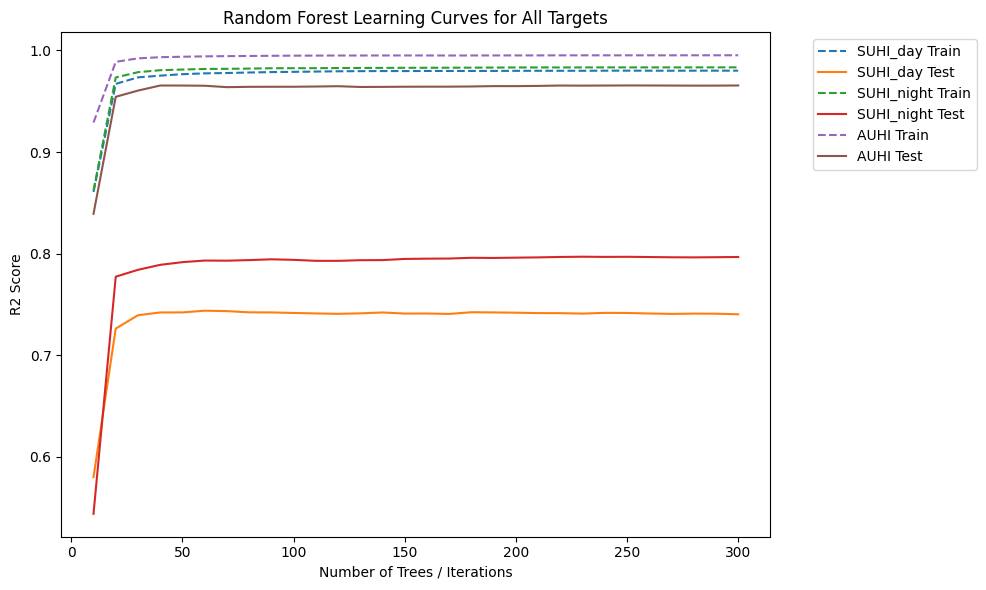

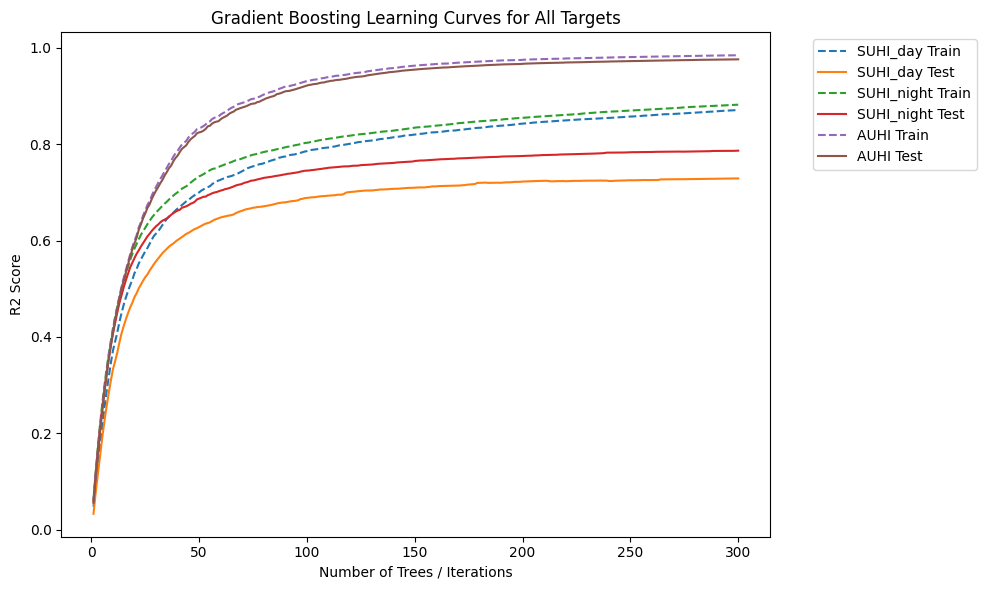

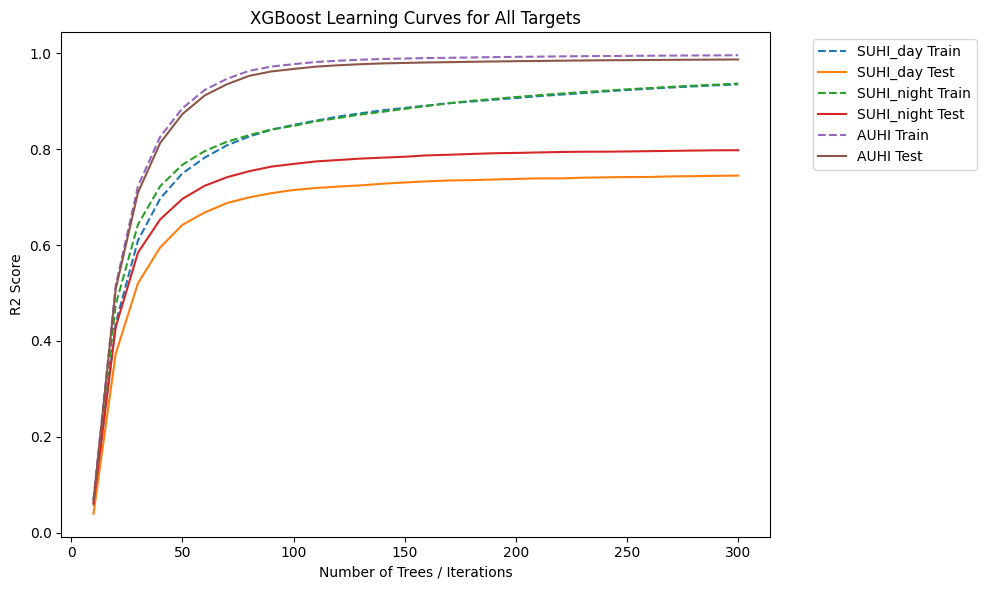

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from model_plots import plot_ensemble_learning_curves

# Call the function
plot_ensemble_learning_curves(tuned_models, X_train, y_train, X_test, y_test, targets, max_trees=300, step=10)

In [17]:
tuned_results = {}

for name, model in tuned_models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    model_results = {}

    for i, target in enumerate(targets):
        r2_train = r2_score(y_train.iloc[:, i], y_pred_train[:, i])
        r2_test = r2_score(y_test.iloc[:, i], y_pred_test[:, i])
        mae_train = mean_absolute_error(y_train.iloc[:, i], y_pred_train[:, i])
        mae_test = mean_absolute_error(y_test.iloc[:, i], y_pred_test[:, i])
        rmse_test = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_test[:, i]))

        model_results[target] = {
            "R2_train": round(r2_train, 3),
            "R2_test": round(r2_test, 3),
            "R2_gap": round(r2_train - r2_test, 3),
            "MAE_train": round(mae_train, 3),
            "MAE_test": round(mae_test, 3),
            "MAE_gap": round(mae_test - mae_train, 3),
            "RMSE_test": round(rmse_test, 3)
        }

    tuned_results[name] = model_results


df_results = pd.DataFrame([
    {"model": model, "target": target, **metrics}
    for model, targets_dict in tuned_results.items()
    for target, metrics in targets_dict.items()
])

display(df_results)

,model,target,R2_train,R2_test,R2_gap,MAE_train,MAE_test,MAE_gap,RMSE_test
0,Random Forest,SUHI_day,0.980,0.740,0.240,0.471,1.660,1.189,2.793
1,Random Forest,SUHI_night,0.983,0.797,0.187,0.268,1.003,0.735,1.448
2,Random Forest,AUHI,0.995,0.966,0.030,0.168,0.430,0.262,0.861
3,Gradient Boosting,SUHI_day,0.871,0.729,0.142,1.330,1.832,0.502,2.851
4,Gradient Boosting,SUHI_night,0.882,0.787,0.095,0.747,1.081,0.334,1.484
5,Gradient Boosting,AUHI,0.985,0.976,0.008,0.392,0.466,0.074,0.713
6,XGBoost,SUHI_day,0.937,0.746,0.191,0.933,1.721,0.789,2.763
7,XGBoost,SUHI_night,0.938,0.798,0.141,0.540,1.035,0.496,1.445
8,XGBoost,AUHI,0.996,0.987,0.009,0.197,0.312,0.115,0.522
9,Linear Regression,SUHI_day,0.481,0.491,-0.011,2.779,2.865,0.086,3.907


### 3.4 Rebuilding Models with UFTVI as Outcome Variable

In [18]:
# New targets including UTFVI
targets_utfvi = ["SUHI_day", "SUHI_night", "AUHI", "UTFVI_day", "UTFVI_night"]

# Rebuild model_df with new targets
model_df_utfvi = uhi_data[features + targets_utfvi].copy()
model_df_utfvi["LandCover"] = model_df_utfvi["LandCover"].astype(int).astype(str)
model_df_utfvi = pd.get_dummies(model_df_utfvi, columns=["LandCover"], prefix="LC")
model_df_utfvi["month_sin"] = np.sin(2 * np.pi * model_df_utfvi["month"] / 12)
model_df_utfvi["month_cos"] = np.cos(2 * np.pi * model_df_utfvi["month"] / 12)
model_df_utfvi = model_df_utfvi.drop(columns=["month"])

# Add lat/lon for pixel-level split
model_df_utfvi["latitude"] = uhi_data["latitude"]
model_df_utfvi["longitude"] = uhi_data["longitude"]

# Pixel-level train/test split
feature_cols_utfvi = [c for c in model_df_utfvi.columns 
                      if c not in targets_utfvi + ["latitude", "longitude"]]

train_mask = model_df_utfvi[["latitude", "longitude"]].apply(tuple, axis=1).isin(
    train_pixels.apply(tuple, axis=1)
)

X_train_utfvi = model_df_utfvi[train_mask][feature_cols_utfvi]
X_test_utfvi = model_df_utfvi[~train_mask][feature_cols_utfvi]
y_train_utfvi = model_df_utfvi[train_mask][targets_utfvi]
y_test_utfvi = model_df_utfvi[~train_mask][targets_utfvi]


current_data_hash_utfvi = hash_data(X_train_utfvi, y_train_utfvi)

tuned_models_utfvi = {}
best_params_log_utfvi = {}

search_configs_utfvi = [
    ("Random Forest",
     MultiOutputRegressor(RandomForestRegressor(random_state=42)),
     rf_params),
    ("Gradient Boosting",
     MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
     gb_params),
    ("XGBoost",
     MultiOutputRegressor(XGBRegressor(random_state=42, verbosity=0)),
     xgb_params)
]

for name, base_model, params in search_configs_utfvi:
    model_path, meta_path = get_paths(f"tuned_{name}_utfvi")
    current_param_hash = hash_dict(params)
    use_cache = False

    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)
        if (
            meta.get("param_hash") == current_param_hash and
            meta.get("data_hash") == current_data_hash_utfvi
        ):
            use_cache = True

    if use_cache:
        print(f"Loading cached {name}_utfvi...")
        tuned_models_utfvi[name] = joblib.load(model_path)
    else:
        print(f"Tuning {name}_utfvi...")
        grid_search = GridSearchCV(
            base_model, params, cv=5, scoring="r2", n_jobs=-1, verbose=1
        )
        grid_search.fit(X_train_utfvi, y_train_utfvi)
        model = grid_search.best_estimator_
        tuned_models_utfvi[name] = model
        best_params_log_utfvi[name] = grid_search.best_params_
        joblib.dump(model, model_path)
        with open(meta_path, "w") as f:
            json.dump({
                "param_hash": current_param_hash,
                "data_hash": current_data_hash_utfvi
            }, f, indent=4)
        print(f"Saved {name}_utfvi")

# Linear models
linear_models_utfvi = {
    "Linear Regression": MultiOutputRegressor(LinearRegression()),
    "Ridge Regression": MultiOutputRegressor(Ridge(alpha=1.0))
}

for name, model in linear_models_utfvi.items():
    model_path, meta_path = get_paths(f"{name}_utfvi")
    use_cache = False

    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)
        if meta.get("data_hash") == current_data_hash_utfvi:
            use_cache = True

    if use_cache:
        print(f"Loading cached {name}_utfvi...")
        tuned_models_utfvi[name] = joblib.load(model_path)
    else:
        print(f"Training {name}_utfvi...")
        model.fit(X_train_utfvi, y_train_utfvi)
        tuned_models_utfvi[name] = model
        joblib.dump(model, model_path)
        with open(meta_path, "w") as f:
            json.dump({"data_hash": current_data_hash_utfvi}, f, indent=4)
        print(f"Saved {name}_utfvi")

Loading cached Random Forest_utfvi...
Loading cached Gradient Boosting_utfvi...
Loading cached XGBoost_utfvi...
Loading cached Linear Regression_utfvi...
Loading cached Ridge Regression_utfvi...


#### 3.4.1 Visualizing Performances on UFTVI Models

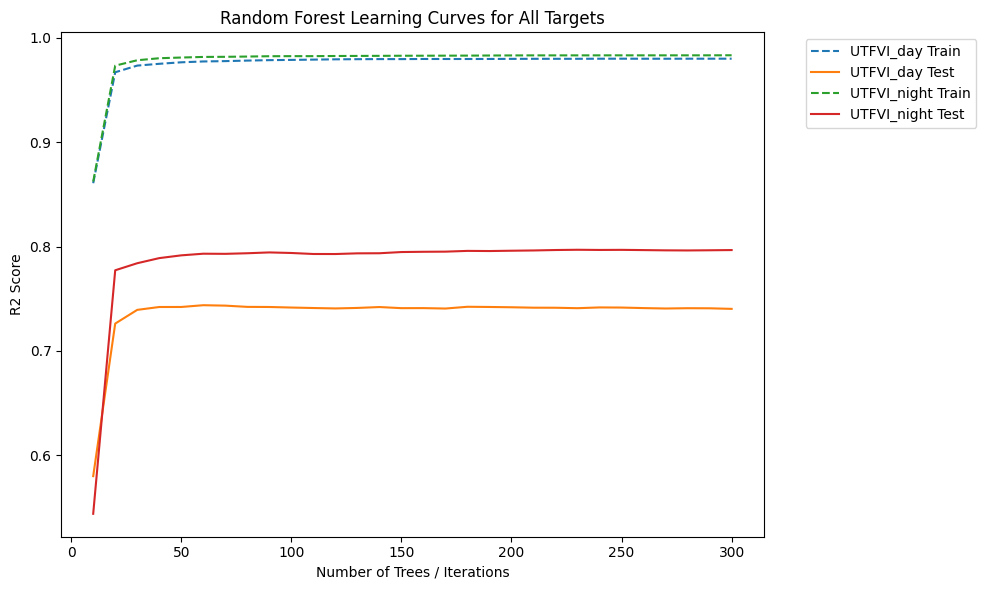

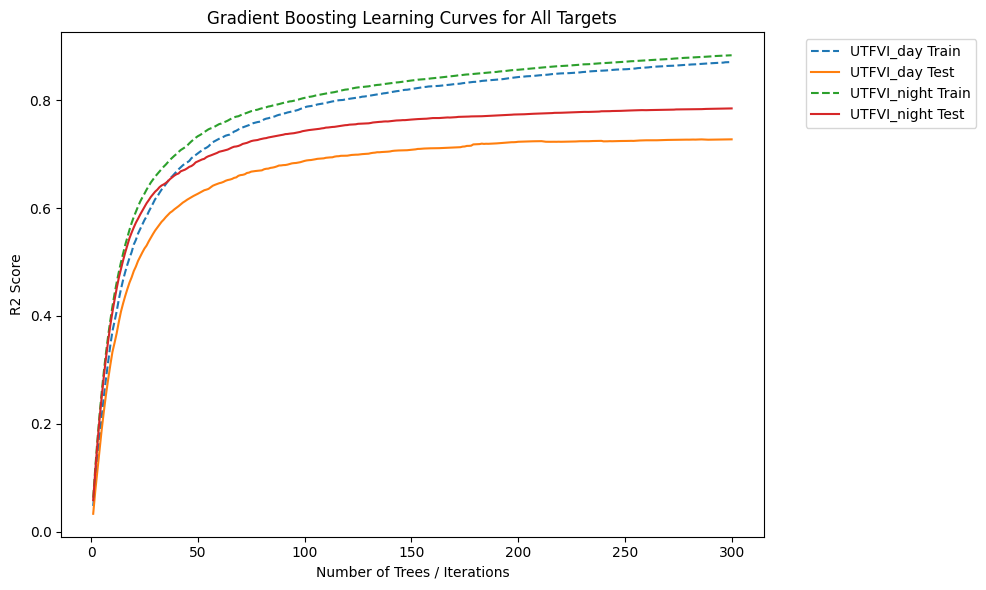

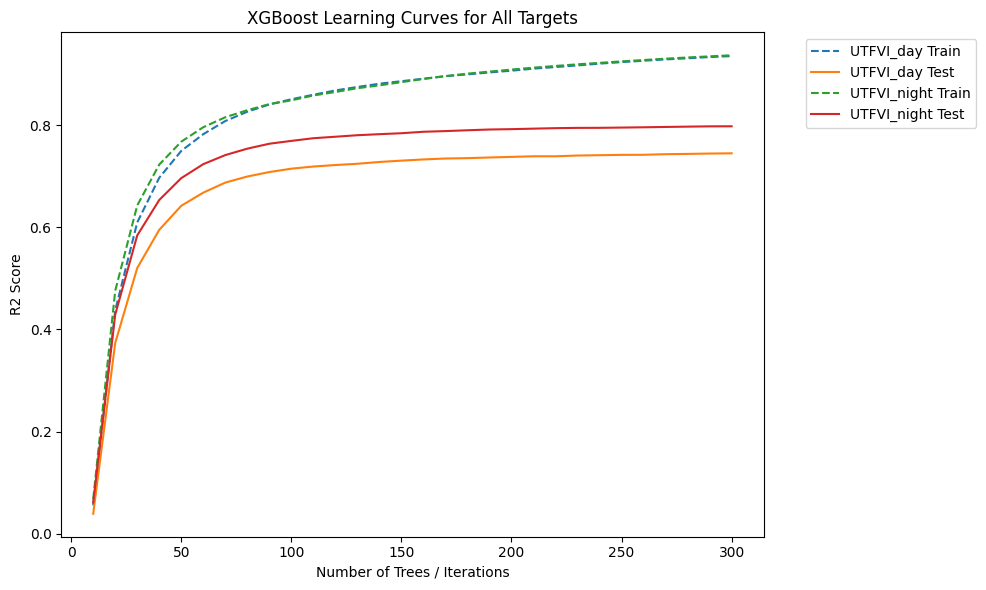

In [19]:
plot_ensemble_learning_curves(tuned_models_utfvi, X_train_utfvi, y_train_utfvi, X_test_utfvi, y_test_utfvi, ["UTFVI_day", "UTFVI_night"], max_trees=300, step=10)

In [20]:
tuned_results_utfvi = {}

for name, model in tuned_models_utfvi.items():
    y_pred_train_utfvi = model.predict(X_train_utfvi)
    y_pred_test_utfvi = model.predict(X_test_utfvi)

    model_results_utfvi = {}

    for i, target in enumerate(targets_utfvi):
        r2_train_utfvi = r2_score(y_train_utfvi.iloc[:, i], y_pred_train_utfvi[:, i])
        r2_test_utfvi = r2_score(y_test_utfvi.iloc[:, i], y_pred_test_utfvi[:, i])
        mae_train_utfvi = mean_absolute_error(y_train_utfvi.iloc[:, i], y_pred_train_utfvi[:, i])
        mae_test_utfvi = mean_absolute_error(y_test_utfvi.iloc[:, i], y_pred_test_utfvi[:, i])
        rmse_test_utfvi = np.sqrt(mean_squared_error(y_test_utfvi.iloc[:, i], y_pred_test_utfvi[:, i]))

        model_results_utfvi[target] = {
            "R2_train": round(r2_train_utfvi, 3),
            "R2_test": round(r2_test_utfvi, 3),
            "R2_gap": round(r2_train_utfvi - r2_test_utfvi, 3),
            "MAE_train": round(mae_train_utfvi, 3),
            "MAE_test": round(mae_test_utfvi, 3),
            "MAE_gap": round(mae_test_utfvi - mae_train_utfvi, 3),
            "RMSE_test": round(rmse_test_utfvi, 3)
        }

    tuned_results_utfvi[name] = model_results_utfvi


df_results_utfvi = pd.DataFrame([
    {"model": model, "target": target, **metrics}
    for model, targets_dict in tuned_results_utfvi.items()
    for target, metrics in targets_dict.items()
])

display(df_results_utfvi)

,model,target,R2_train,R2_test,R2_gap,MAE_train,MAE_test,MAE_gap,RMSE_test
0,Random Forest,SUHI_day,0.980,0.740,0.240,0.471,1.660,1.189,2.793
1,Random Forest,SUHI_night,0.983,0.797,0.187,0.268,1.003,0.735,1.448
2,Random Forest,AUHI,0.995,0.966,0.030,0.168,0.430,0.262,0.861
3,Random Forest,UTFVI_day,0.978,0.716,0.261,0.002,0.006,0.004,0.009
4,Random Forest,UTFVI_night,0.983,0.781,0.202,0.001,0.003,0.003,0.005
5,Gradient Boosting,SUHI_day,0.871,0.728,0.143,1.335,1.828,0.494,2.859
6,Gradient Boosting,SUHI_night,0.884,0.785,0.099,0.744,1.085,0.341,1.490
7,Gradient Boosting,AUHI,0.985,0.976,0.009,0.393,0.474,0.080,0.716
8,Gradient Boosting,UTFVI_day,0.854,0.709,0.145,0.004,0.006,0.002,0.009
9,Gradient Boosting,UTFVI_night,0.877,0.769,0.108,0.003,0.004,0.001,0.005


### 3.5 Rebuilding Models Without Elevation and Coordinates

In [21]:
features_no_geo = ["humidity", "precipitation", "wind_speed", "cloud_cover_low",
                   "air_temperature", "Albedo", "MNDWI", "NDBI", "SAVI", "LandCover", "month"]

targets_utfvi = ["SUHI_day", "SUHI_night", "AUHI", "UTFVI_day", "UTFVI_night"]

model_df_nogeo = uhi_data[features_no_geo + targets_utfvi].copy()
model_df_nogeo["LandCover"] = model_df_nogeo["LandCover"].astype(int).astype(str)
model_df_nogeo = pd.get_dummies(model_df_nogeo, columns=["LandCover"], prefix="LC")
model_df_nogeo["month_sin"] = np.sin(2 * np.pi * model_df_nogeo["month"] / 12)
model_df_nogeo["month_cos"] = np.cos(2 * np.pi * model_df_nogeo["month"] / 12)
model_df_nogeo = model_df_nogeo.drop(columns=["month"])

model_df_nogeo["latitude"] = uhi_data["latitude"]
model_df_nogeo["longitude"] = uhi_data["longitude"]

feature_cols_nogeo = [c for c in model_df_nogeo.columns 
                      if c not in targets_utfvi + ["latitude", "longitude"]]

train_mask = model_df_nogeo[["latitude", "longitude"]].apply(tuple, axis=1).isin(
    train_pixels.apply(tuple, axis=1)
)

X_train_nogeo = model_df_nogeo[train_mask][feature_cols_nogeo]
X_test_nogeo = model_df_nogeo[~train_mask][feature_cols_nogeo]
y_train_nogeo = model_df_nogeo[train_mask][targets_utfvi]
y_test_nogeo = model_df_nogeo[~train_mask][targets_utfvi]

print(f"X_train: {X_train_nogeo.shape}, X_test: {X_test_nogeo.shape}")

X_train: (15192, 21), X_test: (3816, 21)


In [22]:
current_data_hash_nogeo = hash_data(X_train_nogeo, y_train_nogeo)
tuned_models_nogeo = {}

search_configs_nogeo = [
    ("Random Forest", MultiOutputRegressor(RandomForestRegressor(random_state=42)), rf_params),
    ("Gradient Boosting", MultiOutputRegressor(GradientBoostingRegressor(random_state=42)), gb_params),
    ("XGBoost", MultiOutputRegressor(XGBRegressor(random_state=42, verbosity=0)), xgb_params)
]

for name, base_model, params in search_configs_nogeo:
    model_path, meta_path = get_paths(f"tuned_{name}_nogeo")
    current_param_hash = hash_dict(params)
    use_cache = False

    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)
        if (meta.get("param_hash") == current_param_hash and
                meta.get("data_hash") == current_data_hash_nogeo):
            use_cache = True

    if use_cache:
        print(f"Loading cached {name}_nogeo...")
        tuned_models_nogeo[name] = joblib.load(model_path)
    else:
        print(f"Tuning {name}_nogeo...")
        grid_search = GridSearchCV(
            base_model, params, cv=5, scoring="r2", n_jobs=-1, verbose=1
        )
        grid_search.fit(X_train_nogeo, y_train_nogeo)
        model = grid_search.best_estimator_
        tuned_models_nogeo[name] = model
        joblib.dump(model, model_path)
        with open(meta_path, "w") as f:
            json.dump({
                "param_hash": current_param_hash,
                "data_hash": current_data_hash_nogeo
            }, f, indent=4)
        print(f"Saved {name}_nogeo")

for name, model in [
    ("Linear Regression", MultiOutputRegressor(LinearRegression())),
    ("Ridge Regression", MultiOutputRegressor(Ridge(alpha=1.0)))
]:
    model_path, meta_path = get_paths(f"{name}_nogeo")
    use_cache = False
    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)
        if meta.get("data_hash") == current_data_hash_nogeo:
            use_cache = True
    if use_cache:
        print(f"Loading cached {name}_nogeo...")
        tuned_models_nogeo[name] = joblib.load(model_path)
    else:
        print(f"Training {name}_nogeo...")
        model.fit(X_train_nogeo, y_train_nogeo)
        tuned_models_nogeo[name] = model
        joblib.dump(model, model_path)
        with open(meta_path, "w") as f:
            json.dump({"data_hash": current_data_hash_nogeo}, f, indent=4)

Tuning Random Forest_nogeo...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Saved Random Forest_nogeo
Tuning Gradient Boosting_nogeo...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Saved Gradient Boosting_nogeo
Tuning XGBoost_nogeo...
Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
Saved XGBoost_nogeo
Training Linear Regression_nogeo...
Training Ridge Regression_nogeo...


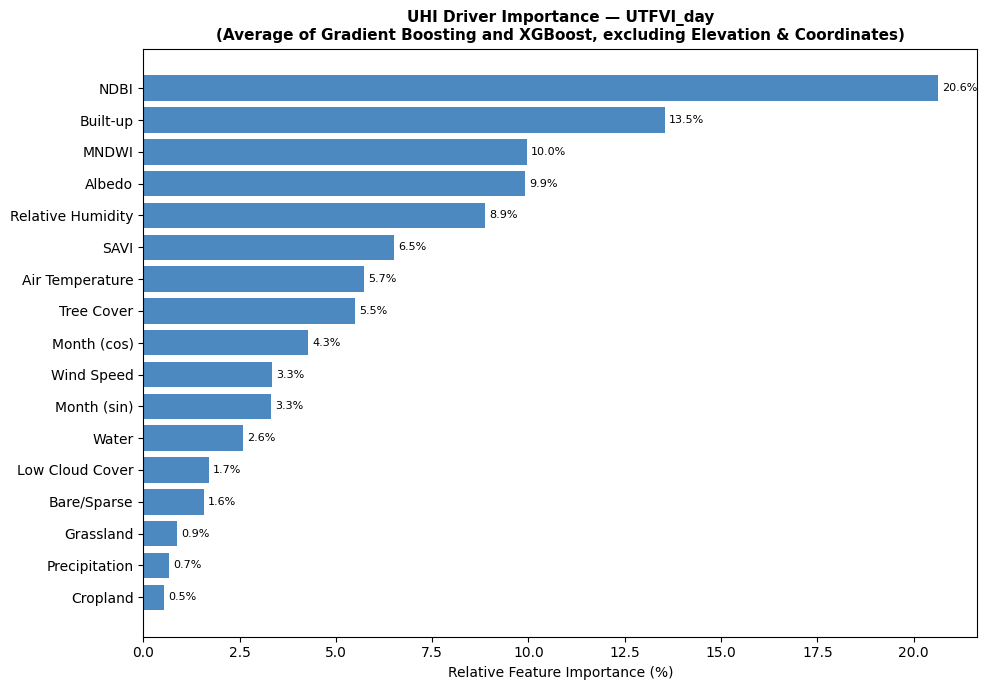

Saved overall UTFVI_day


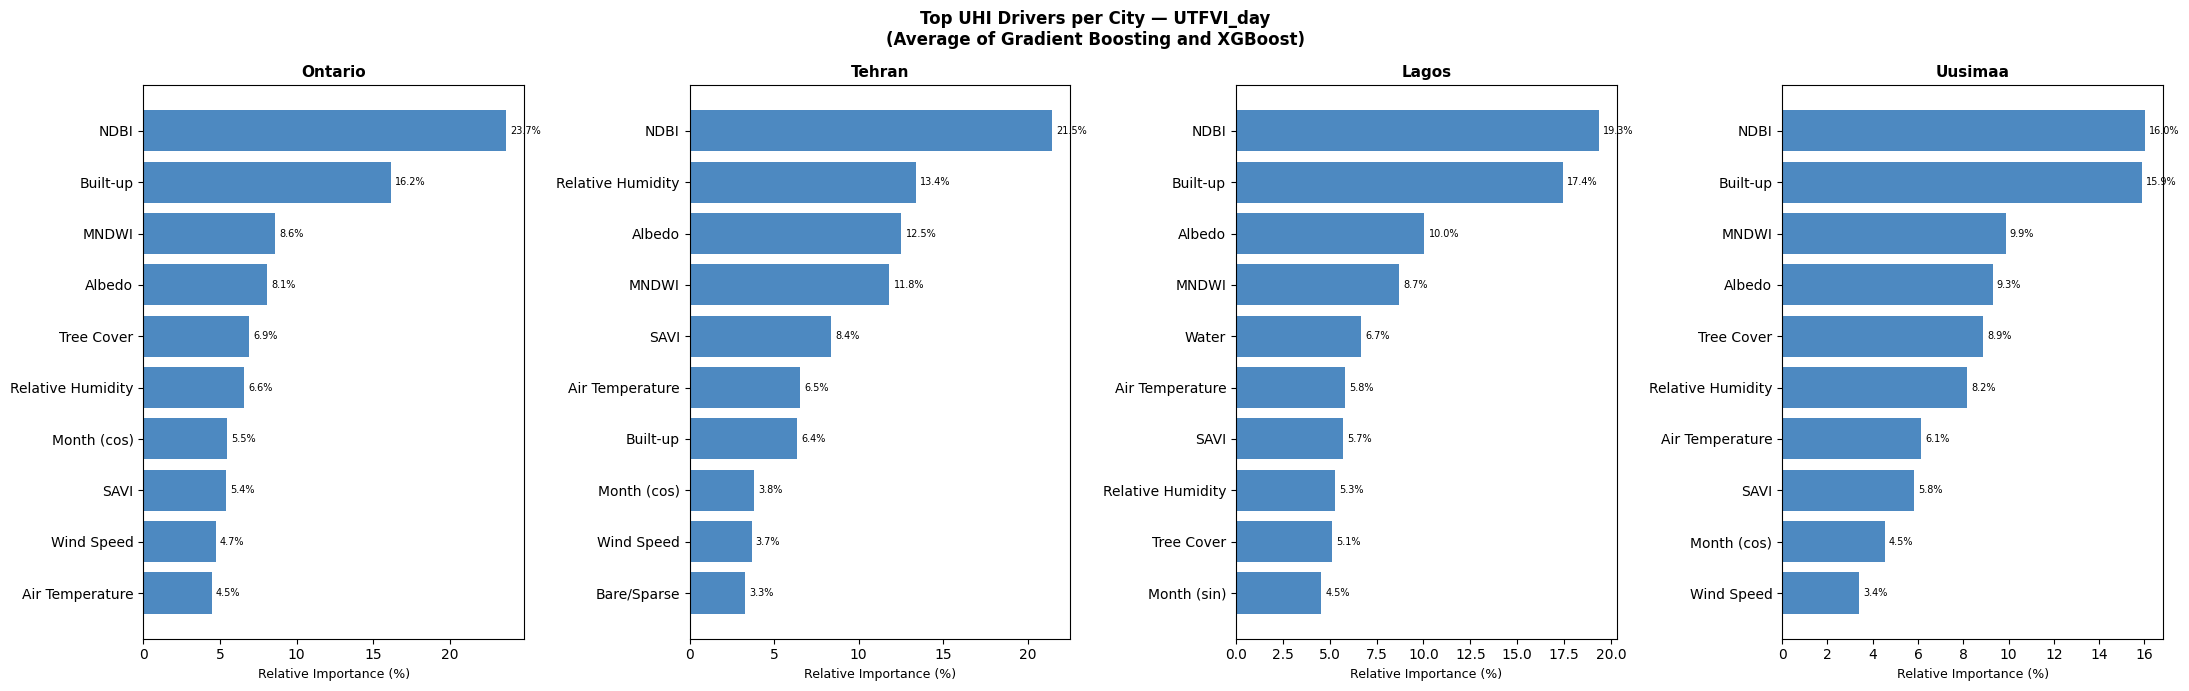

Saved per-city UTFVI_day

--- UTFVI_day Relative Importance Table ---
NDBI                 20.62
Built-up             13.54
MNDWI                 9.95
Albedo                9.90
Relative Humidity     8.88
SAVI                  6.50
Air Temperature       5.73
Tree Cover            5.51
Month (cos)           4.29
Wind Speed            3.33
Month (sin)           3.32
Water                 2.60
Low Cloud Cover       1.70
Bare/Sparse           1.56
Grassland             0.88
Precipitation         0.67
Cropland              0.53


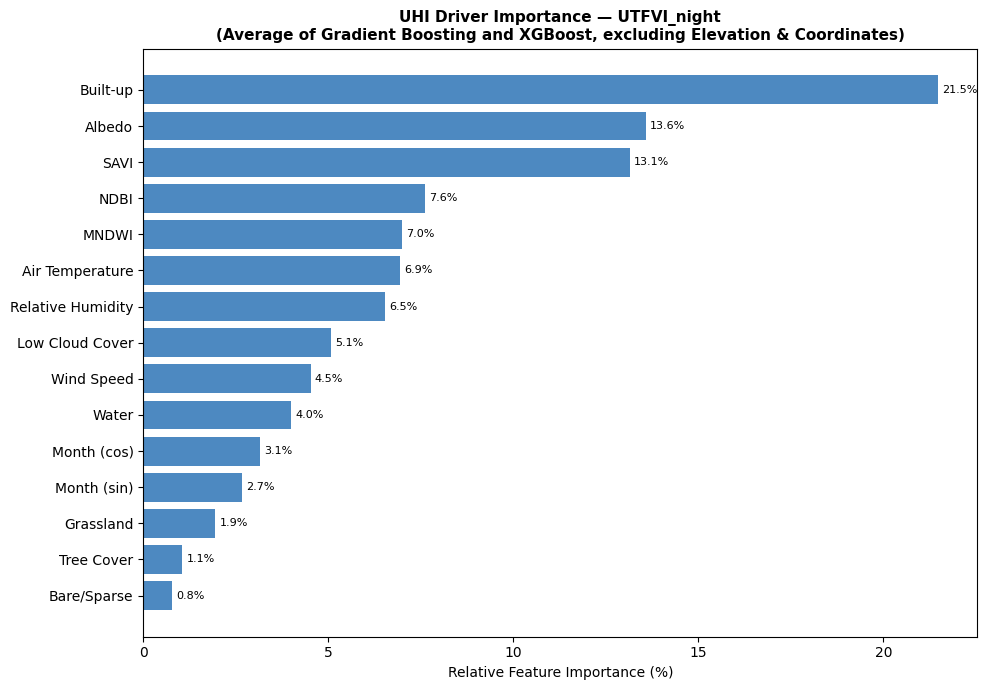

Saved overall UTFVI_night


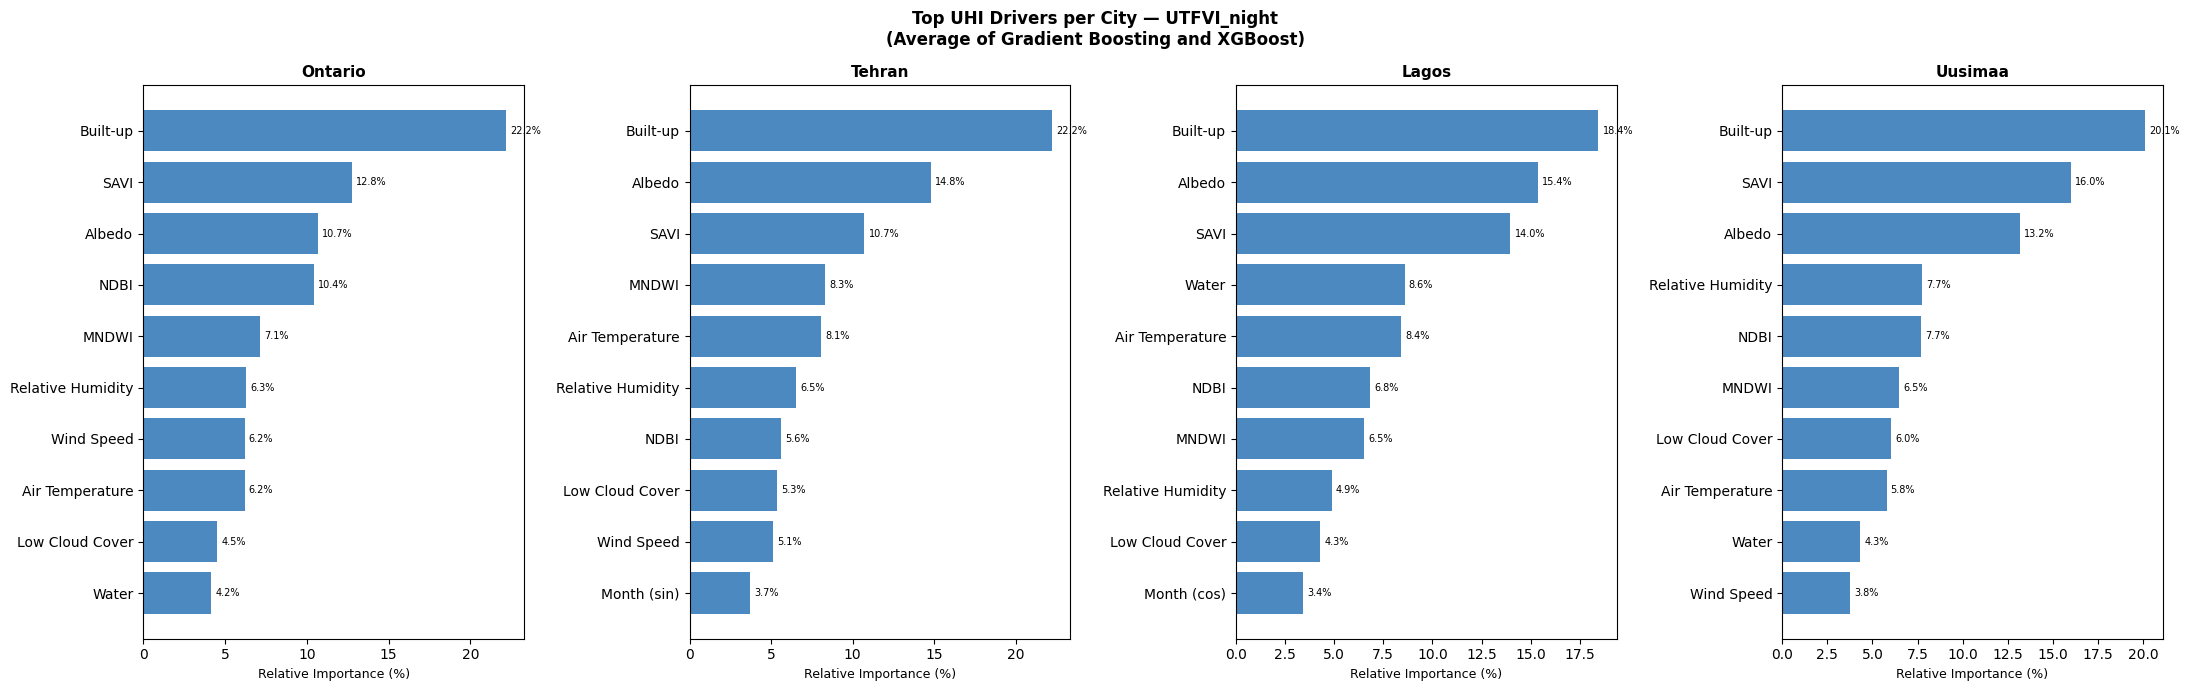

Saved per-city UTFVI_night

--- UTFVI_night Relative Importance Table ---
Built-up             21.47
Albedo               13.58
SAVI                 13.15
NDBI                  7.62
MNDWI                 7.00
Air Temperature       6.95
Relative Humidity     6.53
Low Cloud Cover       5.07
Wind Speed            4.52
Water                 3.99
Month (cos)           3.15
Month (sin)           2.66
Grassland             1.94
Tree Cover            1.06
Bare/Sparse           0.78


In [23]:
import shap
import pandas as pd

os.makedirs("plots/shap/utfvi", exist_ok=True)

utfvi_targets = ["UTFVI_day", "UTFVI_night"]
utfvi_indices = [targets_utfvi.index(t) for t in utfvi_targets]
model_names = ["Gradient Boosting", "XGBoost"]

feature_display_names = {
    "humidity": "Relative Humidity",
    "precipitation": "Precipitation",
    "wind_speed": "Wind Speed",
    "cloud_cover_low": "Low Cloud Cover",
    "air_temperature": "Air Temperature",
    "Albedo": "Albedo",
    "MNDWI": "MNDWI",
    "NDBI": "NDBI",
    "SAVI": "SAVI",
    "month_sin": "Month (sin)",
    "month_cos": "Month (cos)",
    "LC_10": "Tree Cover",
    "LC_20": "Shrubland",
    "LC_30": "Grassland",
    "LC_40": "Cropland",
    "LC_50": "Built-up",
    "LC_60": "Bare/Sparse",
    "LC_80": "Water",
    "LC_90": "Wetland",
    "LC_95": "Mangroves",
    "LC_100": "Moss/Lichen"
}

cities = ["Ontario", "Tehran", "Lagos", "Uusimaa"]

for target, idx in zip(utfvi_targets, utfvi_indices):
    # Collect SHAP across both models
    all_shap = []
    
    for model_name in model_names:
        model = tuned_models_nogeo[model_name]
        estimator = model.estimators_[idx]
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(X_test_nogeo)
        all_shap.append(shap_values)
    
    mean_shap = np.mean(all_shap, axis=0)
    mean_abs_shap = np.abs(mean_shap).mean(axis=0)
    
    # Normalise to percentage of total importance
    mean_abs_shap_pct = mean_abs_shap / mean_abs_shap.sum() * 100
    
    shap_series = pd.Series(mean_abs_shap_pct, index=feature_cols_nogeo)
    shap_series.index = [feature_display_names.get(f, f) for f in shap_series.index]
    
    # Drop near-zero features (< 0.5% importance)
    shap_series = shap_series[shap_series > 0.5].sort_values(ascending=True)
    
    # --- Overall plot ---
    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(shap_series.index, shap_series.values, color="#2E75B6", alpha=0.85)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_xlabel("Relative Feature Importance (%)", fontsize=10)
    ax.set_title(f"UHI Driver Importance — {target}\n(Average of Gradient Boosting and XGBoost, excluding Elevation & Coordinates)",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"plots/shap/utfvi/{target}_overall.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved overall {target}")

    # --- Per city plot ---
    fig, axes = plt.subplots(1, 4, figsize=(22, 7), sharey=False)
    
    for ax, city in zip(axes, cities):
        city_mask = uhi_data.loc[X_test_nogeo.index, "city"] == city
        
        city_shap_list = []
        for model_name in model_names:
            model = tuned_models_nogeo[model_name]
            estimator = model.estimators_[idx]
            explainer = shap.TreeExplainer(estimator)
            shap_values = explainer.shap_values(X_test_nogeo)
            city_shap = np.abs(shap_values[city_mask]).mean(axis=0)
            city_shap_list.append(city_shap)
        
        mean_city_shap = np.mean(city_shap_list, axis=0)
        mean_city_shap_pct = mean_city_shap / mean_city_shap.sum() * 100
        
        city_series = pd.Series(mean_city_shap_pct, index=feature_cols_nogeo)
        city_series.index = [feature_display_names.get(f, f) for f in city_series.index]
        city_series = city_series[city_series > 0.5].sort_values(ascending=True).tail(10)
        
        bars = ax.barh(city_series.index, city_series.values, color="#2E75B6", alpha=0.85)
        ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=7)
        ax.set_title(city, fontsize=11, fontweight="bold")
        ax.set_xlabel("Relative Importance (%)", fontsize=9)
    
    fig.suptitle(f"Top UHI Drivers per City — {target}\n(Average of Gradient Boosting and XGBoost)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"plots/shap/utfvi/{target}_per_city.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved per-city {target}")

    # Print table
    print(f"\n--- {target} Relative Importance Table ---")
    print(shap_series.sort_values(ascending=False).round(2).to_string())

## 4. Results

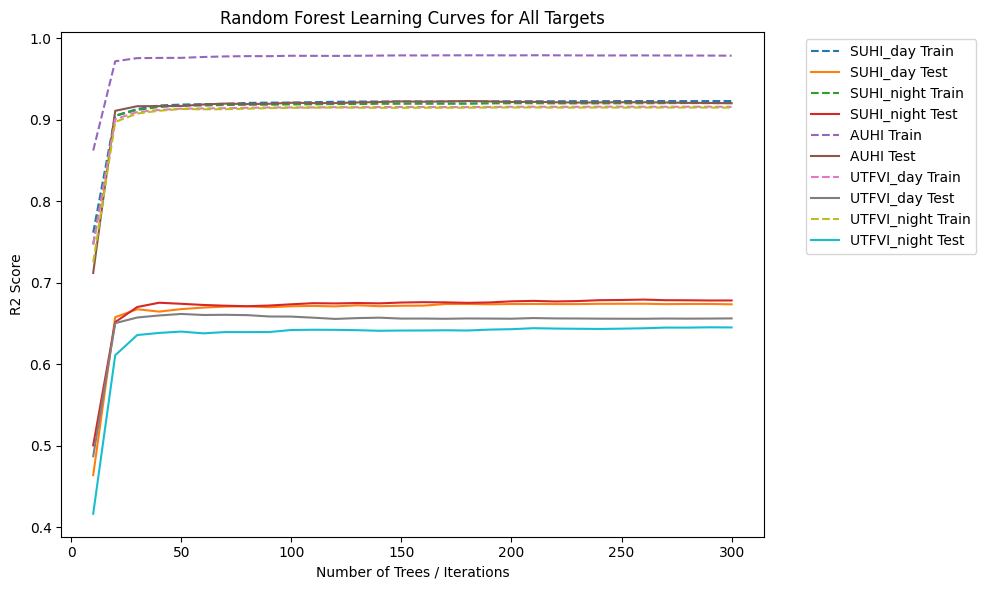

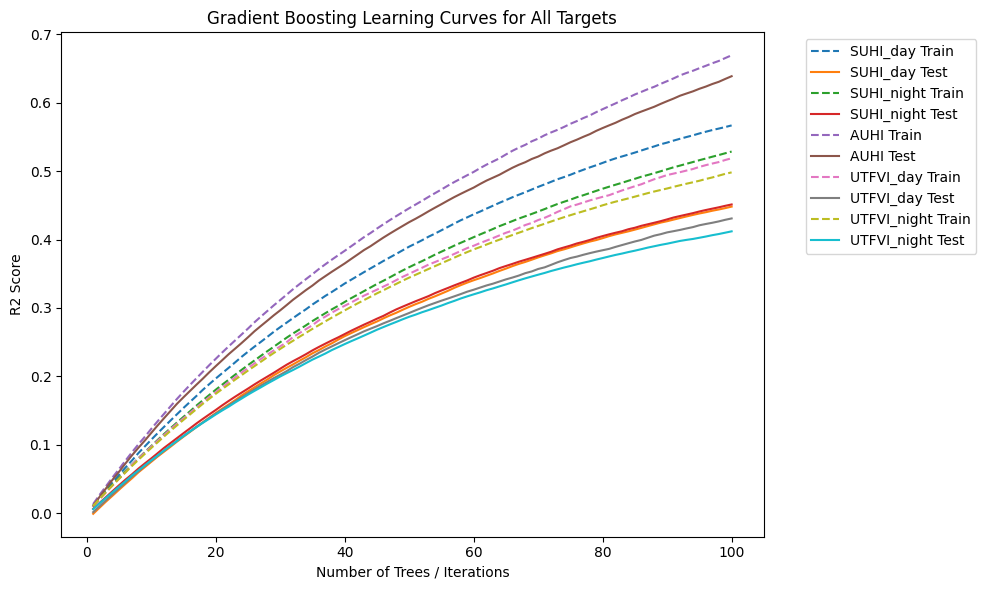

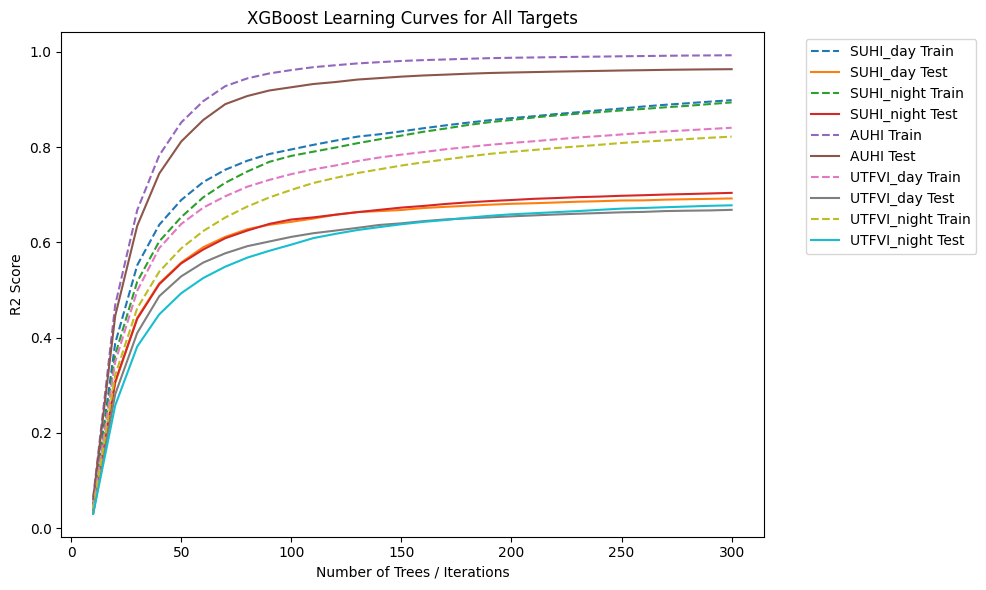

In [26]:
plot_ensemble_learning_curves(tuned_models_nogeo, X_train_nogeo, y_train_nogeo, X_test_nogeo, y_test_nogeo, targets_utfvi, max_trees=300, step=10)

In [30]:
tuned_results_nogeo = {}
for name, model in tuned_models_nogeo.items():
    y_pred_train_nogeo = model.predict(X_train_nogeo)
    y_pred_test_nogeo = model.predict(X_test_nogeo)
    model_results_nogeo = {}  
    for i, target in enumerate(targets_utfvi):
        r2_train = r2_score(y_train_nogeo.iloc[:, i], y_pred_train_nogeo[:, i])
        r2_test = r2_score(y_test_nogeo.iloc[:, i], y_pred_test_nogeo[:, i])
        mae_train = mean_absolute_error(y_train_nogeo.iloc[:, i], y_pred_train_nogeo[:, i])
        mae_test = mean_absolute_error(y_test_nogeo.iloc[:, i], y_pred_test_nogeo[:, i])
        rmse_test = np.sqrt(mean_squared_error(y_test_nogeo.iloc[:, i], y_pred_test_nogeo[:, i]))
        model_results_nogeo[target] = {  # fixed
            "R2_train": round(r2_train, 3),
            "R2_test": round(r2_test, 3),
            "R2_gap": round(r2_train - r2_test, 3),
            "MAE_train": round(mae_train, 3),
            "MAE_test": round(mae_test, 3),
            "MAE_gap": round(mae_test - mae_train, 3),
            "RMSE_test": round(rmse_test, 3)
        }
    tuned_results_nogeo[name] = model_results_nogeo  # fixed

df_results_nogeo = pd.DataFrame([
    {"model": model, "target": target, **metrics}
    for model, targets_dict in tuned_results_nogeo.items()
    for target, metrics in targets_dict.items()
])
display(df_results_nogeo)

,model,target,R2_train,R2_test,R2_gap,MAE_train,MAE_test,MAE_gap,RMSE_test
0,Random Forest,SUHI_day,0.923,0.674,0.249,0.920,1.841,0.921,3.127
1,Random Forest,SUHI_night,0.920,0.678,0.242,0.545,1.126,0.582,1.823
2,Random Forest,AUHI,0.979,0.922,0.057,0.330,0.592,0.262,1.293
3,Random Forest,UTFVI_day,0.916,0.657,0.259,0.003,0.006,0.003,0.010
4,Random Forest,UTFVI_night,0.915,0.644,0.271,0.002,0.004,0.002,0.006
5,Gradient Boosting,SUHI_day,0.567,0.448,0.119,2.464,2.671,0.207,4.069
6,Gradient Boosting,SUHI_night,0.529,0.451,0.077,1.466,1.666,0.200,2.380
7,Gradient Boosting,AUHI,0.670,0.639,0.031,1.890,1.976,0.086,2.785
8,Gradient Boosting,UTFVI_day,0.519,0.431,0.088,0.008,0.009,0.001,0.013
9,Gradient Boosting,UTFVI_night,0.498,0.412,0.086,0.005,0.005,0.001,0.008


In [22]:
import shap
import os

os.makedirs("plots/shap", exist_ok=True)
os.makedirs("plots/shap/Gradient Boosting", exist_ok=True)
os.makedirs("plots/shap/XGBoost", exist_ok=True)

cities = ["Ontario", "Tehran", "Lagos", "Uusimaa"]

def plot_shap_for_model(model_dict, model_name, X_test_data, targets_list, path):
    model = model_dict[model_name]
    
    for i, target in enumerate(targets_list):
        estimator = model.estimators_[i]
        
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(X_test_data)
        
        # --- Overall SHAP summary plot ---
        plt.figure()
        shap.summary_plot(
            shap_values, X_test_data,
            plot_type="bar",
            show=False
        )
        plt.title(f"{model_name} — {target} — Overall Feature Importance", 
                  fontsize=12, fontweight="bold", pad=10)
        plt.tight_layout()
        plt.savefig(f"plots/shap/{path}/{model_name.lower().replace(' ', '_')}_{target}_overall.png", 
                    dpi=150, bbox_inches="tight")
        plt.close()

        # --- Per city SHAP summary plots ---
        for city in cities:
            city_mask = uhi_data.loc[X_test_data.index, "city"] == city
            X_city = X_test_data[city_mask]
            shap_city = shap_values[city_mask]
            
            if len(X_city) == 0:
                print(f"No test data for {city} — skipping")
                continue
            
            plt.figure()
            shap.summary_plot(
                shap_city, X_city,
                plot_type="bar",
                show=False
            )
            plt.title(f"{model_name} — {target} — {city}", 
                      fontsize=12, fontweight="bold", pad=10)
            plt.tight_layout()
            plt.savefig(
                f"plots/shap/{path}/{model_name.lower().replace(' ', '_')}_{target}_{city.lower()}.png",
                dpi=150, bbox_inches="tight"
            )
            plt.close()
            print(f"Saved: {model_name} — {target} — {city}")

# Original targets — Gradient Boosting and XGBoost
for model_name in ["Gradient Boosting", "XGBoost"]:
    print(f"\n{'='*40}")
    print(f"Computing SHAP — {model_name} — Original targets")
    print(f"{'='*40}")
    plot_shap_for_model(tuned_models, model_name, X_test, targets, path = model_name)

# UTFVI targets — Gradient Boosting and XGBoost
for model_name in ["Gradient Boosting", "XGBoost"]:
    print(f"\n{'='*40}")
    print(f"Computing SHAP — {model_name} — UTFVI targets")
    print(f"{'='*40}")
    plot_shap_for_model(tuned_models_utfvi, model_name, X_test_utfvi, targets_utfvi, path = model_name)


Computing SHAP — Gradient Boosting — Original targets
Saved: Gradient Boosting — SUHI_day — Ontario
Saved: Gradient Boosting — SUHI_day — Tehran
Saved: Gradient Boosting — SUHI_day — Lagos
Saved: Gradient Boosting — SUHI_day — Uusimaa
Saved: Gradient Boosting — SUHI_night — Ontario
Saved: Gradient Boosting — SUHI_night — Tehran
Saved: Gradient Boosting — SUHI_night — Lagos
Saved: Gradient Boosting — SUHI_night — Uusimaa
Saved: Gradient Boosting — AUHI — Ontario
Saved: Gradient Boosting — AUHI — Tehran
Saved: Gradient Boosting — AUHI — Lagos
Saved: Gradient Boosting — AUHI — Uusimaa

Computing SHAP — XGBoost — Original targets
Saved: XGBoost — SUHI_day — Ontario
Saved: XGBoost — SUHI_day — Tehran
Saved: XGBoost — SUHI_day — Lagos
Saved: XGBoost — SUHI_day — Uusimaa
Saved: XGBoost — SUHI_night — Ontario
Saved: XGBoost — SUHI_night — Tehran
Saved: XGBoost — SUHI_night — Lagos
Saved: XGBoost — SUHI_night — Uusimaa
Saved: XGBoost — AUHI — Ontario
Saved: XGBoost — AUHI — Tehran
Saved: XGBoo

In [24]:
print("climate" in uhi_data.columns)
print(uhi_data.columns)

False
Index(['date', 'humidity', 'precipitation', 'wind_speed', 'cloud_cover_low',
       'air_temperature', 'latitude', 'longitude', 'LandCover', 'Elevation',
       'city', 'month', 'time', 'Albedo', 'LST_day', 'LST_night', 'MNDWI',
       'NDBI', 'NDVI', 'SAVI', 'is_urban', 'rural_mean_LST_day',
       'rural_mean_LST_night', 'rural_mean_airtemp', 'SUHI_day', 'SUHI_night',
       'AUHI', 'UTFVI_day', 'UTFVI_night'],
      dtype='object')


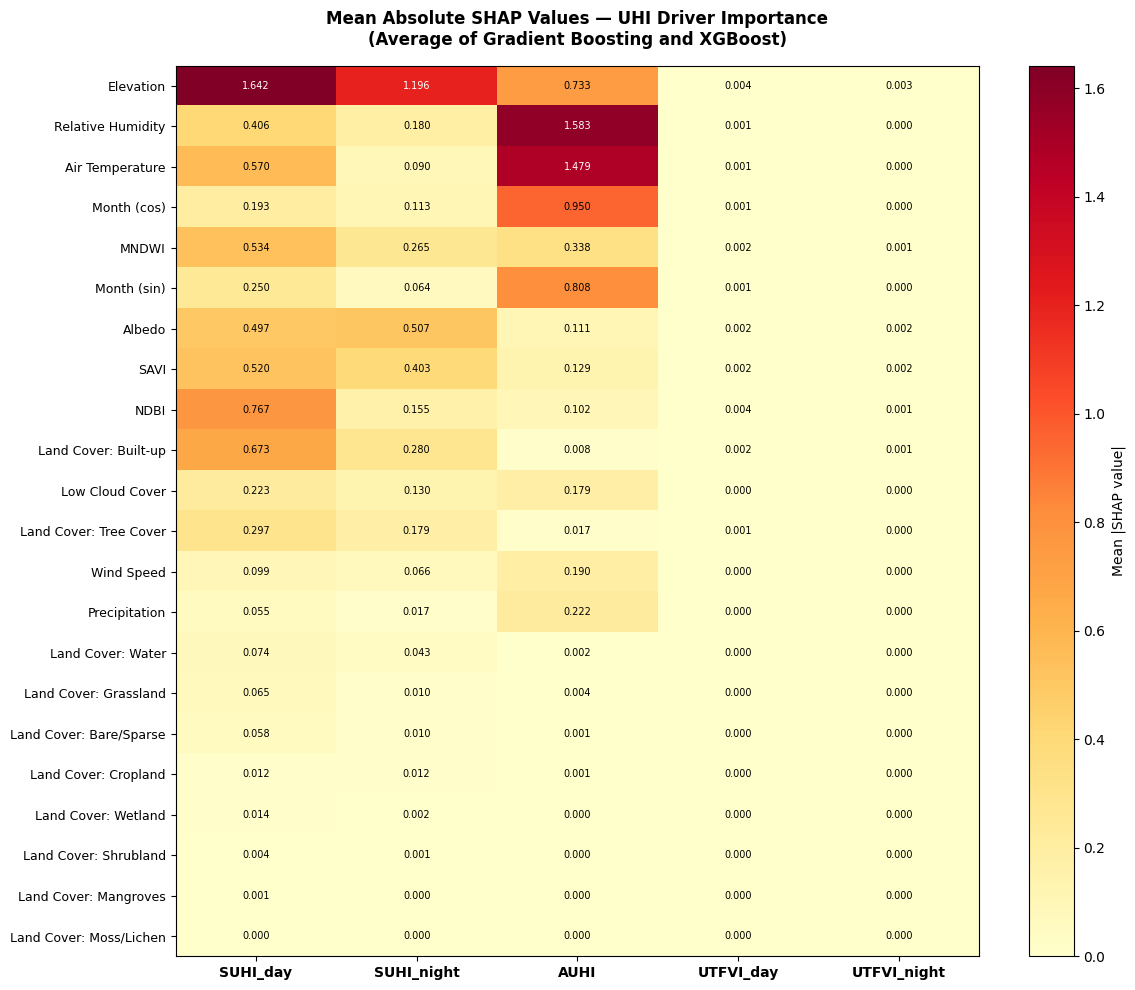

In [28]:
import numpy as np

# Collect mean absolute SHAP per feature per target across both models
model_names = ["Gradient Boosting", "XGBoost"]
all_shap = {target: [] for target in targets_utfvi}

feature_display_names = {
    "humidity": "Relative Humidity",
    "precipitation": "Precipitation",
    "wind_speed": "Wind Speed",
    "cloud_cover_low": "Low Cloud Cover",
    "air_temperature": "Air Temperature",
    "latitude": "Latitude",
    "longitude": "Longitude",
    "Elevation": "Elevation",
    "Albedo": "Albedo",
    "MNDWI": "MNDWI",
    "NDBI": "NDBI",
    "SAVI": "SAVI",
    "month_sin": "Month (sin)",
    "month_cos": "Month (cos)",
    "LC_10": "Land Cover: Tree Cover",
    "LC_20": "Land Cover: Shrubland",
    "LC_30": "Land Cover: Grassland",
    "LC_40": "Land Cover: Cropland",
    "LC_50": "Land Cover: Built-up",
    "LC_60": "Land Cover: Bare/Sparse",
    "LC_80": "Land Cover: Water",
    "LC_90": "Land Cover: Wetland",
    "LC_95": "Land Cover: Mangroves",
    "LC_100": "Land Cover: Moss/Lichen"
}

for model_name in model_names:
    model = tuned_models_utfvi[model_name]
    for i, target in enumerate(targets_utfvi):
        estimator = model.estimators_[i]
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(X_test_utfvi)
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        all_shap[target].append(mean_abs_shap)

# Average across both models
shap_matrix = np.array([
    np.mean(all_shap[target], axis=0) for target in targets_utfvi
]).T  # shape: (n_features, n_targets)

shap_df = pd.DataFrame(
    shap_matrix,
    index=feature_cols_utfvi,
    columns=targets_utfvi
)

# Apply to shap_df index before plotting
shap_df.index = [feature_display_names.get(f, f) for f in shap_df.index]

# Sort by mean importance across all targets
shap_df["mean"] = shap_df.mean(axis=1)
shap_df = shap_df.sort_values("mean", ascending=False).drop(columns="mean")

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(shap_df.values, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax, label="Mean |SHAP value|")

ax.set_xticks(range(len(targets_utfvi)))
ax.set_yticks(range(len(shap_df)))
ax.set_xticklabels(targets_utfvi, fontsize=10, fontweight="bold")
ax.set_yticklabels(shap_df.index, fontsize=9)

for r in range(len(shap_df)):
    for c in range(len(targets_utfvi)):
        ax.text(c, r, f"{shap_df.values[r, c]:.3f}",
                ha="center", va="center", fontsize=7,
                color="white" if shap_df.values[r, c] > shap_df.values.max()*0.6 else "black")

ax.set_title("Mean Absolute SHAP Values — UHI Driver Importance\n(Average of Gradient Boosting and XGBoost)",
             fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("plots/shap/shap_global_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

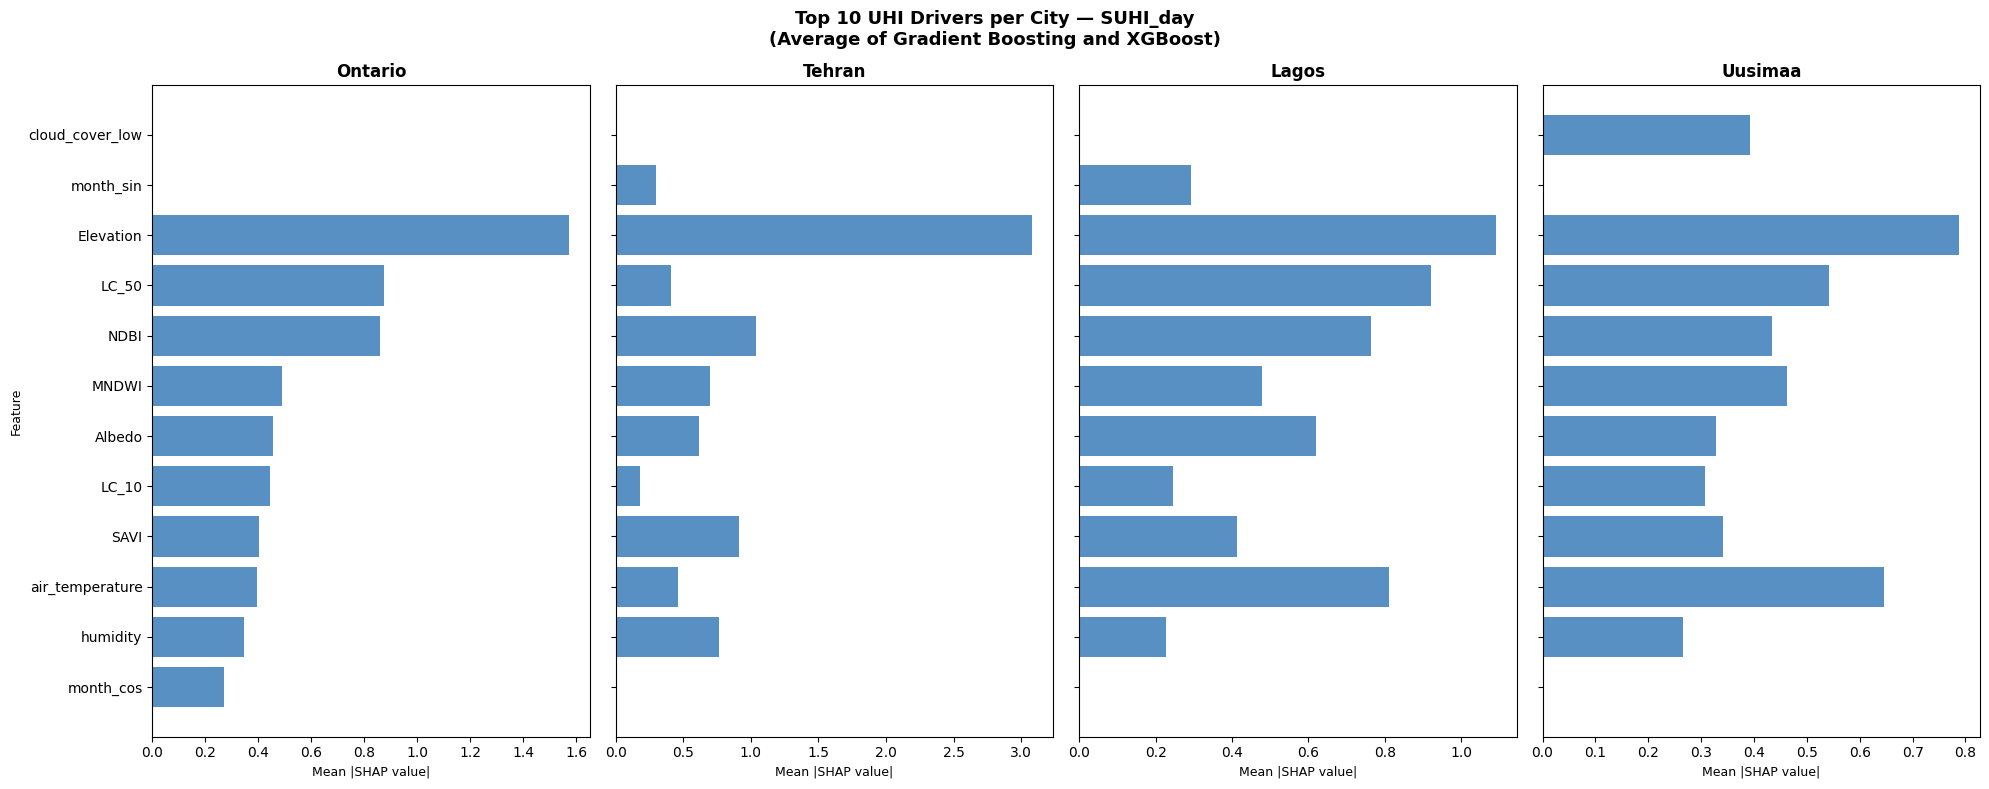

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(20, 8), sharey=True)
city_list = ["Ontario", "Tehran", "Lagos", "Uusimaa"]

for ax, city in zip(axes, city_list):
    city_shap_list = []
    
    for model_name in model_names:
        model = tuned_models_utfvi[model_name]
        estimator = model.estimators_[0]  # SUHI_day
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(X_test_utfvi)
        
        city_mask = uhi_data.loc[X_test_utfvi.index, "city"] == city
        city_shap = np.abs(shap_values[city_mask]).mean(axis=0)
        city_shap_list.append(city_shap)
    
    mean_city_shap = np.mean(city_shap_list, axis=0)
    city_shap_df = pd.Series(mean_city_shap, index=feature_cols_utfvi).sort_values(ascending=True)
    
    # Show top 10 features only
    city_shap_df = city_shap_df.tail(10)
    
    ax.barh(city_shap_df.index, city_shap_df.values, color="#2E75B6", alpha=0.8)
    ax.set_title(city, fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean |SHAP value|", fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel("Feature", fontsize=9)

fig.suptitle("Top 10 UHI Drivers per City — SUHI_day\n(Average of Gradient Boosting and XGBoost)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/shap/shap_per_city_SUHI_day.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
print(shap_df.round(4).to_string())

# Also save to CSV
shap_df.round(4).to_csv("results/shap_global_importance.csv")

                 SUHI_day  SUHI_night    AUHI  UTFVI_day  UTFVI_night
Elevation          1.6418      1.1964  0.7329     0.0042       0.0027
humidity           0.4059      0.1803  1.5829     0.0008       0.0005
air_temperature    0.5705      0.0900  1.4788     0.0008       0.0003
month_cos          0.1928      0.1135  0.9496     0.0006       0.0003
MNDWI              0.5336      0.2654  0.3381     0.0018       0.0009
month_sin          0.2500      0.0641  0.8077     0.0006       0.0002
Albedo             0.4965      0.5069  0.1108     0.0016       0.0017
SAVI               0.5196      0.4027  0.1285     0.0019       0.0015
NDBI               0.7669      0.1553  0.1018     0.0037       0.0009
LC_50              0.6729      0.2802  0.0080     0.0017       0.0014
cloud_cover_low    0.2230      0.1297  0.1785     0.0004       0.0003
LC_10              0.2965      0.1789  0.0171     0.0014       0.0005
wind_speed         0.0994      0.0659  0.1903     0.0003       0.0002
precipitation      0